# Assignment 3: Bivariate Exploratory Data Analysis

**Student names:** Alexeyenko Artyom and Akparov Dilshat

**Student IDs:** 37463 and 37341 

**Course:** Exploratory Data Analysis 

**Dataset:** `BankChurners.csv`


## 0. Continuity with Assignments 1 and 2; data checks

Assignment 1 established that customers who left have lower transaction activity, age has almost no association with activity, and card categories have very unequal sizes. Assignment 2 showed right-skewed credit limits and transaction amounts, identified high values using the 1.5 × IQR rule, and retained plausible extreme customers. This analysis studies pairs of variables and explicitly revisits those extreme records. `Unknown` remains a recorded category rather than being silently imputed. The raw data and units are unchanged.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

df = pd.read_csv('BankChurners.csv')
assert df.shape == (10127, 23)
assert df['CLIENTNUM'].is_unique
assert df.isna().sum().sum() == 0
assert df.duplicated().sum() == 0
assert (df['Credit_Limit'] > 0).all()
print(f'Rows: {len(df):,}; columns: {df.shape[1]}; missing cells: {df.isna().sum().sum()}; duplicate rows: {df.duplicated().sum()}')
print(df['Attrition_Flag'].value_counts().to_string())
print('Columns excluded as previous model outputs:', sum(c.startswith('Naive_Bayes_Classifier_') for c in df.columns))
plt.rcParams.update({'figure.dpi': 115, 'axes.grid': True, 'grid.alpha': .2, 'axes.spines.top': False, 'axes.spines.right': False})

Rows: 10,127; columns: 23; missing cells: 0; duplicate rows: 0
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Columns excluded as previous model outputs: 2


## 1. Three primary variable pairs

| Pair | Variables | Why investigate? |
|---|---|---|
| 1, numerical–numerical | `Total_Trans_Ct` and `Total_Trans_Amt` | Counts and amounts together explain spending intensity; Assignment 1 used both separately for churn. |
| 2, numerical–numerical | `Credit_Limit` and `Total_Trans_Amt` | Assignment 2 found strong upper tails in both; we can test whether available credit is associated with actual spending and whether extremes influence Pearson's coefficient. |
| 3, numerical–categorical | `Total_Trans_Amt` and `Attrition_Flag` | Extends Assignment 1's churn comparison using distributions and robust summaries from Assignment 2. |

`Credit_Limit` versus `Avg_Utilization_Ratio` is an **additional** pair for the required nonlinearity check. `Card_Category` is an additional grouping variable, and attrition status is used to stratify pair 1.

## 2. Two numerical scatterplots

The dense point clouds use transparent markers so the concentration and tails remain visible. Axes retain the original data units.

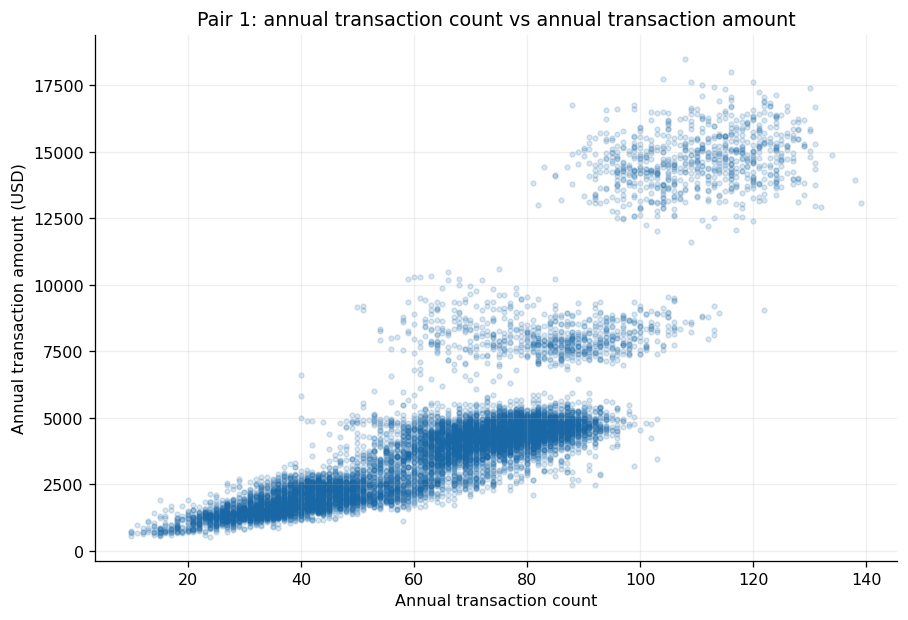

In [2]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(df['Total_Trans_Ct'], df['Total_Trans_Amt'], s=9, alpha=.16, color='#1967a5', rasterized=True)
ax.set(title='Pair 1: annual transaction count vs annual transaction amount', xlabel='Annual transaction count', ylabel='Annual transaction amount (USD)')
fig.tight_layout()
plt.show()

**Figure 1.** A strong positive, approximately monotonic relationship: customers making more transactions generally spend more. The cloud broadens at higher counts, so a single line does not capture every customer's average transaction size. High-amount observations above about $8,619 and the rare counts above 135 are visible near the upper edge. The high-activity region may contain different spending profiles, not necessarily errors.

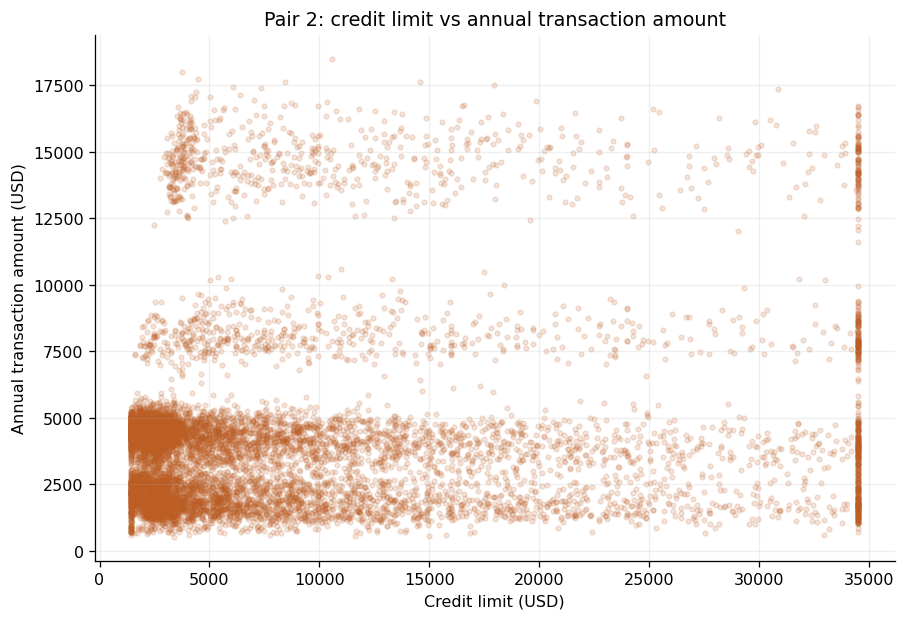

In [3]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(df['Credit_Limit'], df['Total_Trans_Amt'], s=9, alpha=.16, color='#bc5d24', rasterized=True)
ax.set(title='Pair 2: credit limit vs annual transaction amount', xlabel='Credit limit (USD)', ylabel='Annual transaction amount (USD)')
fig.tight_layout()
plt.show()

**Figure 2.** The overall linear trend is weak and the point cloud is widely dispersed. A noticeable vertical stack at the maximum limit of $34,516 shows repeated capped values; it should not be read as 508 independent limit levels. High spending occurs at both moderate and high limits. The shape is heterogeneous, so a small positive Pearson coefficient alone could be misleading.

## 3. Pearson versus Spearman

Pearson measures linear association in original units. Spearman is Pearson applied to ranks and captures monotonic association, with average ranks for ties. Neither coefficient on its own establishes causation, and their magnitudes are not effect sizes in USD.

In [4]:
pairs = [('Total_Trans_Ct', 'Total_Trans_Amt'), ('Credit_Limit', 'Total_Trans_Amt')]
correlation_rows = []
for x, y in pairs:
    correlation_rows.append({'Pair': f'{x} / {y}', 'Pearson': df[x].corr(df[y]), 'Spearman': df[x].rank().corr(df[y].rank())})
corr_table = pd.DataFrame(correlation_rows).set_index('Pair')
print(corr_table.round(4).to_string())

                                  Pearson  Spearman
Pair                                               
Total_Trans_Ct / Total_Trans_Amt   0.8072    0.8797
Credit_Limit / Total_Trans_Amt     0.1717    0.0284


For count versus amount, Pearson ≈ **0.8072** and Spearman ≈ **0.8797**. The ranking relation is even tighter than a straight-line fit, consistent with an increasing but somewhat uneven cloud and high-value tails. For limit versus amount, Pearson ≈ **0.1717**, whereas Spearman ≈ **0.0284**. High observations and the limit cap raise the linear coefficient while the overall rank ordering is almost absent. This difference is a reason to inspect the scatterplot and sensitivity analysis rather than assert a general spending increase with limit.

## 4. Nonlinear supplemental relationship

We use `Credit_Limit` and `Avg_Utilization_Ratio` to inspect shape. The utilization ratio is related by construction to revolving balance divided by available limit, so a downward relation is partly mathematical. The line connects medians within 20 approximately equal-frequency limit bins; it is a descriptive smoother, not a fitted causal model.

Pearson: -0.483
Spearman: -0.417


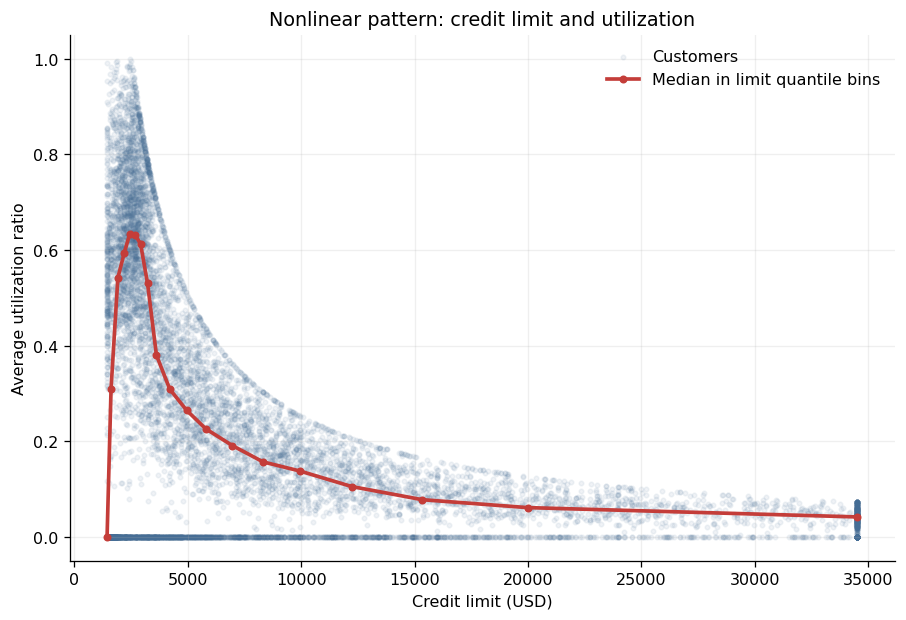

In [5]:
smooth = (df.assign(limit_bin=pd.qcut(df['Credit_Limit'], q=20, duplicates='drop'))
          .groupby('limit_bin', observed=True)
          .agg(limit=('Credit_Limit', 'median'), utilization=('Avg_Utilization_Ratio', 'median'), n=('CLIENTNUM', 'size')))
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(df['Credit_Limit'], df['Avg_Utilization_Ratio'], s=8, alpha=.08, color='#456d95', rasterized=True, label='Customers')
ax.plot(smooth['limit'], smooth['utilization'], '-o', lw=2.3, ms=4, color='#c43d39', label='Median in limit quantile bins')
ax.set(title='Nonlinear pattern: credit limit and utilization', xlabel='Credit limit (USD)', ylabel='Average utilization ratio')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()
print('Pearson:', round(df['Credit_Limit'].corr(df['Avg_Utilization_Ratio']), 4))
print('Spearman:', round(df['Credit_Limit'].rank().corr(df['Avg_Utilization_Ratio'].rank()), 4))

**Figure 3.** The median utilization first rises from the lowest-limit bin, peaks near limits of roughly $2,000–$3,000, and then declines sharply before flattening near zero at high limits. This is **nonlinear and not globally monotonic**. Pearson ≈ **−0.4830** expresses an average negative linear tendency but hides the initial rise and ceiling/floor effects; Spearman ≈ **−0.4170** is likewise only a single summary. At $34,516 the limit is capped for many customers, and a utilization ratio of zero occurs frequently. The ratio's definition also creates a built-in relationship with the denominator.

## 5. Unusual observations and sensitivity of pair 2

Assignment 2's 1.5 × IQR fences are recomputed here for the two monetary variables. The first sensitivity test removes **only two named records** to measure their individual influence. A second, explicitly broader test removes every record beyond either fence. These are diagnostic subsets: the original analysis retains all customers.

In [6]:
def upper_iqr_fence(series):
    q1, q3 = series.quantile([.25, .75])
    return q3 + 1.5 * (q3 - q1)

limit_fence = upper_iqr_fence(df['Credit_Limit'])
amount_fence = upper_iqr_fence(df['Total_Trans_Amt'])
limit_outlier = df['Credit_Limit'] > limit_fence
amount_outlier = df['Total_Trans_Amt'] > amount_fence
focus_ids = [810347208, 718140783]
focus = df.loc[df['CLIENTNUM'].isin(focus_ids), ['CLIENTNUM', 'Attrition_Flag', 'Income_Category', 'Card_Category', 'Credit_Limit', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Avg_Utilization_Ratio']]
print(f'Upper fences: limit = ${limit_fence:,.2f} ({limit_outlier.sum()} above); amount = ${amount_fence:,.2f} ({amount_outlier.sum()} above)')
print(focus.to_string(index=False))

Upper fences: limit = $23,836.25 (984 above); amount = $8,619.25 (896 above)
 CLIENTNUM    Attrition_Flag Income_Category Card_Category  Credit_Limit  Total_Trans_Amt  Total_Trans_Ct  Avg_Utilization_Ratio
 810347208 Existing Customer         $120K +          Gold       34516.0             1330              31                  0.066
 718140783 Existing Customer     $60K - $80K          Blue       10585.0            18484             108                  0.165


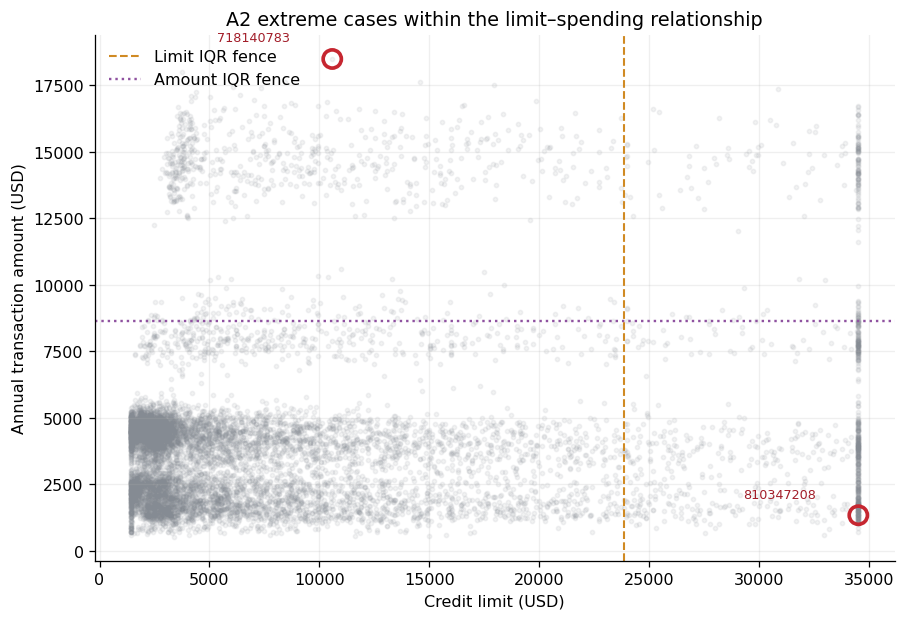

In [7]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(df['Credit_Limit'], df['Total_Trans_Amt'], s=7, alpha=.1, color='#858b93', rasterized=True)
ax.axvline(limit_fence, ls='--', lw=1.3, color='#d08a23', label='Limit IQR fence')
ax.axhline(amount_fence, ls=':', lw=1.5, color='#8f52a0', label='Amount IQR fence')
for _, row in focus.iterrows():
    ax.scatter(row['Credit_Limit'], row['Total_Trans_Amt'], s=130, facecolors='none', edgecolors='#c62630', lw=2.3, zorder=5)
    ax.annotate(str(int(row['CLIENTNUM'])), (row['Credit_Limit'], row['Total_Trans_Amt']), xytext=(-72, 11), textcoords='offset points', fontsize=8, color='#a21d29')
ax.set(title='A2 extreme cases within the limit–spending relationship', xlabel='Credit limit (USD)', ylabel='Annual transaction amount (USD)')
ax.legend(frameon=False, loc='upper left')
fig.tight_layout()
plt.show()

**Figure 4, unusual-observation view 1.** Customer **810347208** has the maximum $34,516 limit but only $1,330 in transactions, 31 transactions, a Gold card and an income category of `$120K +`. A large limit need not mean large spending. Customer **718140783** has the maximum $18,484 in spending, 108 transactions and a $10,585 limit; the high count supports a plausible active customer. Both are coherent records and are kept.

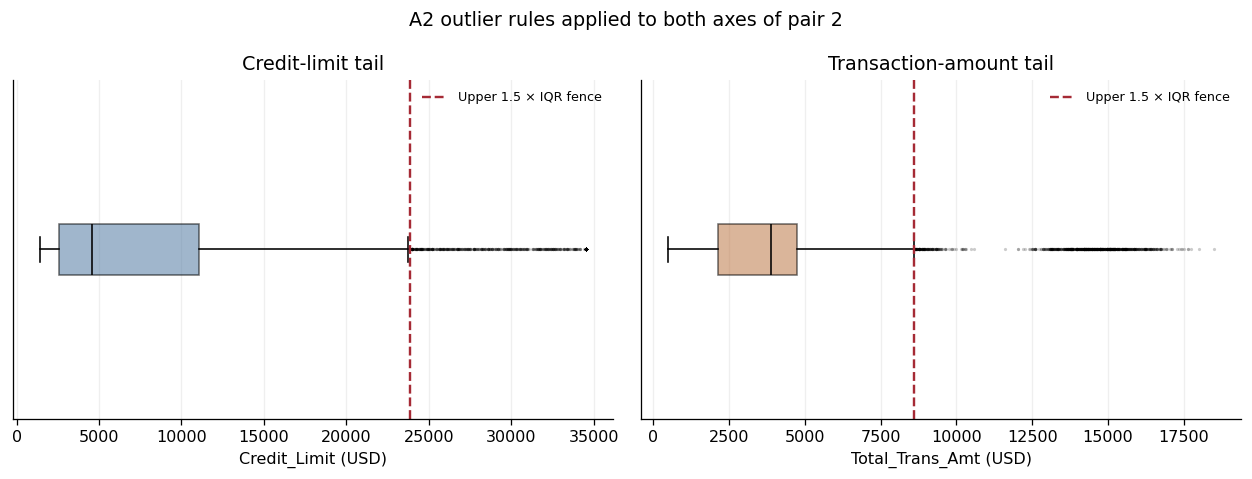

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, col, color, fence, title in zip(axes, ['Credit_Limit', 'Total_Trans_Amt'], ['#537ba3', '#bd7847'], [limit_fence, amount_fence], ['Credit-limit tail', 'Transaction-amount tail']):
    ax.boxplot(df[col], vert=False, patch_artist=True, boxprops={'facecolor': color, 'alpha': .55}, medianprops={'color': 'black'}, flierprops={'marker': '.', 'markersize': 2, 'alpha': .2})
    ax.axvline(fence, color='#a52a35', ls='--', lw=1.5, label='Upper 1.5 × IQR fence')
    ax.set(title=title, xlabel=f'{col} (USD)', yticks=[])
    ax.legend(frameon=False, fontsize=8)
fig.suptitle('A2 outlier rules applied to both axes of pair 2')
fig.tight_layout()
plt.show()

**Figure 5, unusual-observation view 2.** Both monetary distributions have long upper tails. IQR flags are screening rules, not evidence of mistaken entries. The fixed cap at $34,516 also produces a pile of identical limit values. We keep the full dataset for the main coefficients and show filtered coefficients only as sensitivity checks.

In [9]:
def pair_corr(frame):
    x, y = frame['Credit_Limit'], frame['Total_Trans_Amt']
    return {'n': len(frame), 'Pearson': x.corr(y), 'Spearman': x.rank().corr(y.rank())}

sensitivity = pd.DataFrame({
    'All customers': pair_corr(df),
    'Without two named cases': pair_corr(df.loc[~df['CLIENTNUM'].isin(focus_ids)]),
    'Without limit IQR flags': pair_corr(df.loc[~limit_outlier]),
    'Without amount IQR flags': pair_corr(df.loc[~amount_outlier]),
    'Without either IQR flag': pair_corr(df.loc[~(limit_outlier | amount_outlier)]),
}).T
print(sensitivity.round(4).to_string())

                                n  Pearson  Spearman
All customers             10127.0   0.1717    0.0284
Without two named cases   10125.0   0.1721    0.0285
Without limit IQR flags    9143.0   0.1288   -0.0020
Without amount IQR flags   9231.0   0.0274   -0.0966
Without either IQR flag    8443.0  -0.0257   -0.1105


The two named customers hardly change Pearson (**0.1717 → 0.1721**), so neither individually drives the observed relation. Removing all 896 high-amount cases gives Pearson about **0.0274**, and removing either monetary tail gives about **−0.0257**. That is a much larger change, showing **collective tail sensitivity**, but the filtered groups describe a different population and do not justify deleting valid customers. Spearman is near zero overall and becomes negative in the heavily filtered subset, another sign that there is no stable single monotonic relation.

## 6. Numerical versus categorical: spending and attrition

The boxplot compares medians, IQRs and visible upper tails; the next plot shows the empirical cumulative distribution (ECDF), so group overlap is visible without assuming a normal distribution. Group sample sizes are shown in the legends or title.

                      n  median     mean       q1       q3
Attrition_Flag                                            
Attrited Customer  1627  2329.0  3095.03  1903.50  2772.00
Existing Customer  8500  4100.0  4654.66  2384.75  4781.25


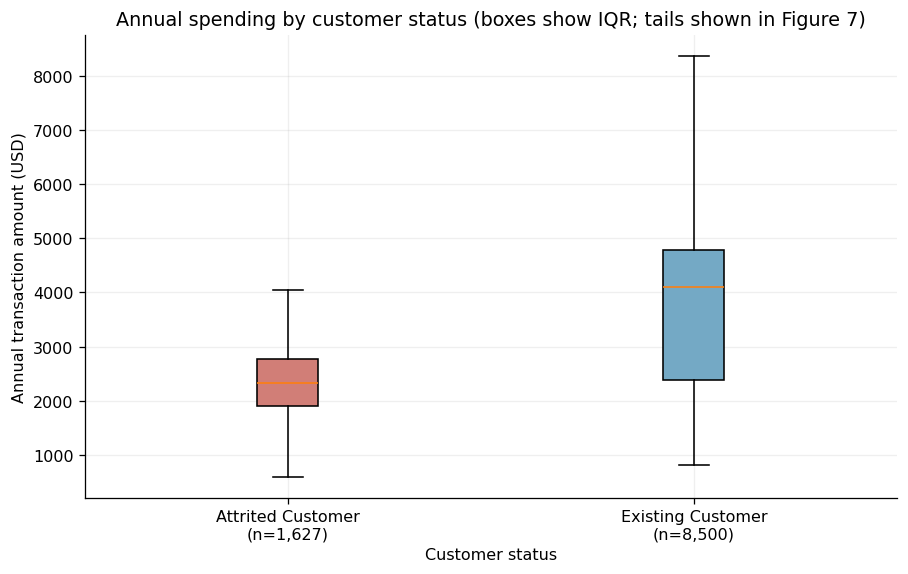

In [10]:
order = ['Attrited Customer', 'Existing Customer']
groups = [df.loc[df['Attrition_Flag'].eq(label), 'Total_Trans_Amt'] for label in order]
fig, ax = plt.subplots(figsize=(8, 5.1))
b = ax.boxplot(groups, tick_labels=[f'{label}\n(n={len(g):,})' for label, g in zip(order, groups)], patch_artist=True, showfliers=False)
for patch, color in zip(b['boxes'], ['#d17e77', '#74a9c5']): patch.set_facecolor(color)
ax.set(title='Annual spending by customer status (boxes show IQR; tails shown in Figure 7)', xlabel='Customer status', ylabel='Annual transaction amount (USD)')
fig.tight_layout()
plt.show()
summary = df.groupby('Attrition_Flag')['Total_Trans_Amt'].agg(n='size', median='median', mean='mean', q1=lambda s: s.quantile(.25), q3=lambda s: s.quantile(.75))
print(summary.round(2).to_string())

**Figure 6, group comparison 1.** Attrited customers have median annual spending of **$2,329** (IQR $1,903.50–$2,772), versus **$4,100** (IQR $2,384.75–$4,781.25) for existing customers. The IQRs overlap, so status does not perfectly separate individual spending. Whiskers omit plotted fliers for readability; observations and statistics remain in the data. The categories are imbalanced (1,627 versus 8,500), so comparisons should use within-group distributions.

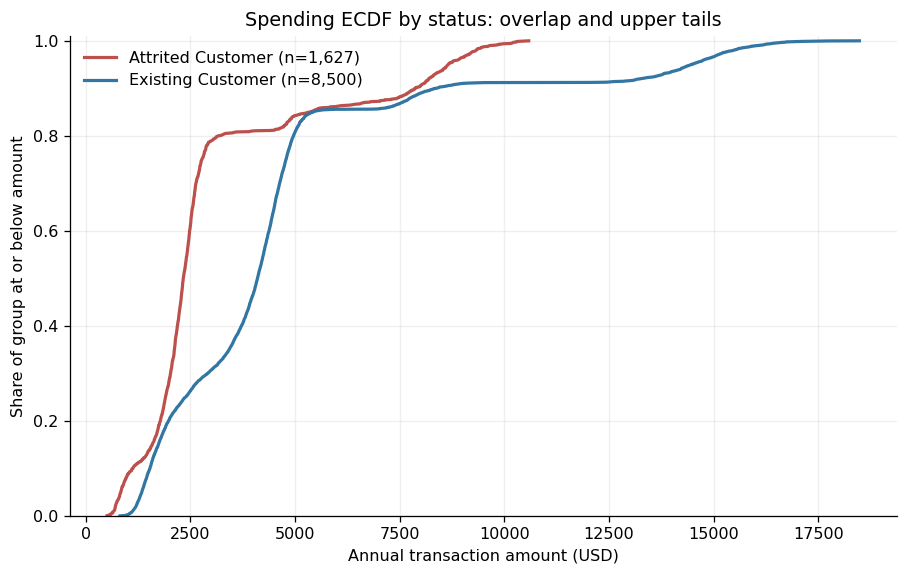

In [11]:
fig, ax = plt.subplots(figsize=(8, 5.1))
for label, color in zip(order, ['#bb504c', '#3276a4']):
    values = np.sort(df.loc[df['Attrition_Flag'].eq(label), 'Total_Trans_Amt'].to_numpy())
    ax.plot(values, np.arange(1, len(values)+1)/len(values), label=f'{label} (n={len(values):,})', color=color, lw=2)
ax.set(title='Spending ECDF by status: overlap and upper tails', xlabel='Annual transaction amount (USD)', ylabel='Share of group at or below amount', ylim=(0, 1.01))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

**Figure 7, additional bivariate view 1.** The existing-customer ECDF is shifted toward higher spending through much of the range, but the curves approach each other in the upper tail. This reveals overlap and high spenders in both groups that a median-only statement hides. It supports the earlier Assignment 1 conclusion while adding the robust distributional context from Assignment 2.

                  n   median        q1       q3
Card_Category                                  
Blue           9436   4105.0   2476.00   9070.0
Gold            116  34516.0  22724.25  34516.0
Platinum         20  34516.0  31882.25  34516.0
Silver          555  29808.0  15153.00  34516.0


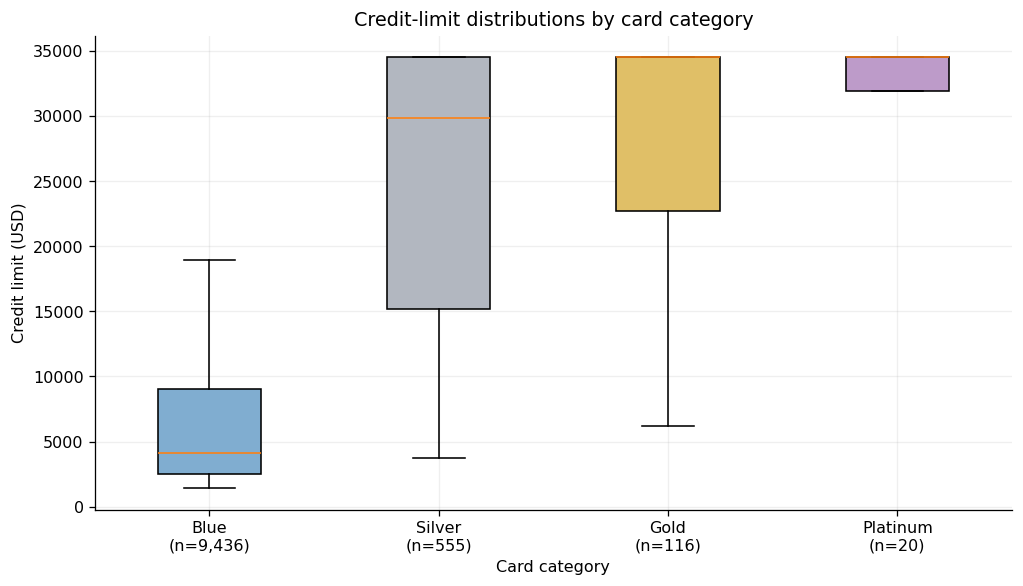

In [12]:
card_order = ['Blue', 'Silver', 'Gold', 'Platinum']
card_groups = [df.loc[df['Card_Category'].eq(label), 'Credit_Limit'] for label in card_order]
fig, ax = plt.subplots(figsize=(9, 5.2))
b = ax.boxplot(card_groups, tick_labels=[f'{name}\n(n={len(g):,})' for name, g in zip(card_order, card_groups)], patch_artist=True, showfliers=False)
for patch, color in zip(b['boxes'], ['#80add0', '#b2b7c0', '#e0bf67', '#bd9bc9']): patch.set_facecolor(color)
ax.set(title='Credit-limit distributions by card category', xlabel='Card category', ylabel='Credit limit (USD)')
fig.tight_layout()
plt.show()
print(df.groupby('Card_Category')['Credit_Limit'].agg(n='size', median='median', q1=lambda s:s.quantile(.25), q3=lambda s:s.quantile(.75)).round(2).to_string())

**Figure 8, group comparison 2.** Median limits rise from **$4,105** for Blue to **$29,808** for Silver and **$34,516** for Gold and Platinum. The ranges overlap, while many premium-card observations sit at the common $34,516 cap. Gold (116) and especially Platinum (20) are small groups compared with Blue (9,436), so premium-group summaries are less stable. The cap limits what can be inferred about latent higher credit capacity.

## 7. The count–amount relationship within attrition groups

Separate panels keep the same scales to prevent visual exaggeration. Each line is an ordinary least-squares trend for description, not a causal effect estimate.

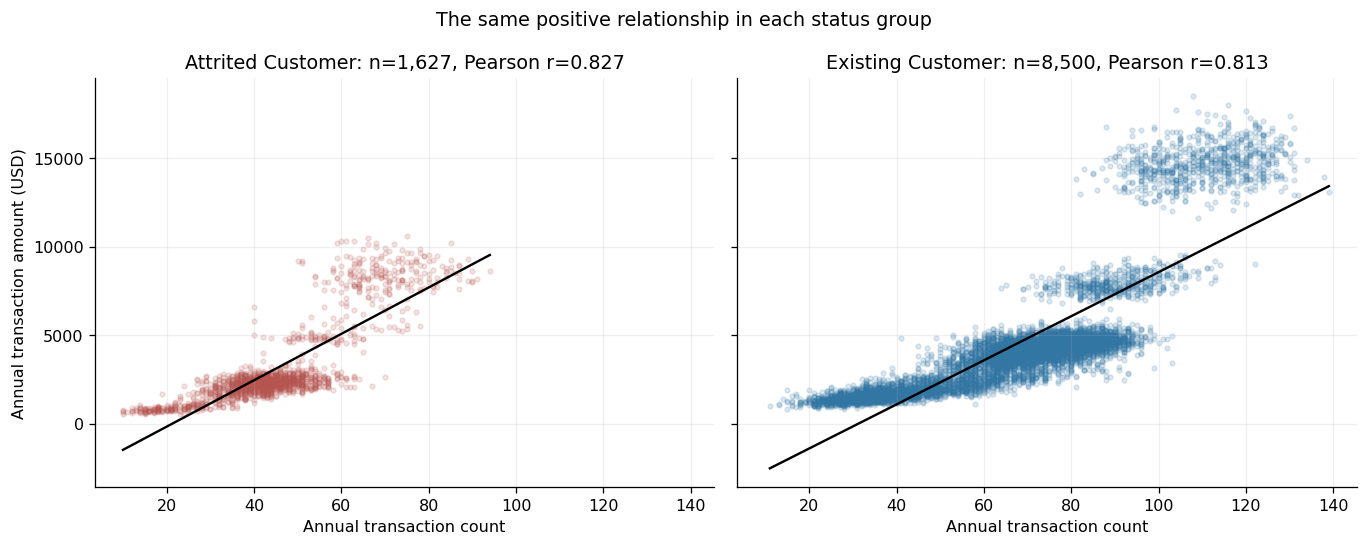

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True, sharey=True)
for ax, label, color in zip(axes, order, ['#b65550', '#3276a4']):
    g = df[df['Attrition_Flag'].eq(label)]
    x, y = g['Total_Trans_Ct'].to_numpy(), g['Total_Trans_Amt'].to_numpy()
    ax.scatter(x, y, s=9, alpha=.16, color=color, rasterized=True)
    xx = np.array([x.min(), x.max()]); ax.plot(xx, np.polyval(np.polyfit(x, y, 1), xx), color='black', lw=1.5)
    ax.set(title=f'{label}: n={len(g):,}, Pearson r={g.Total_Trans_Ct.corr(g.Total_Trans_Amt):.3f}', xlabel='Annual transaction count')
axes[0].set_ylabel('Annual transaction amount (USD)')
fig.suptitle('The same positive relationship in each status group')
fig.tight_layout()
plt.show()

**Figure 9.** Both groups retain a positive count–amount association: Pearson ≈ **0.827** among attrited and **0.813** among existing customers, versus 0.807 overall. Stratification does not reverse the direction, but it reveals lower typical activity and a narrower main cluster for attrited customers; the high-activity/high-amount region is more populated by existing customers. Grouping is therefore informative even without Simpson's paradox.

## 8. Correlation matrix

Only original substantive numeric columns are included. `CLIENTNUM` is an identifier, and `Avg_Open_To_Buy` is omitted because it is nearly `Credit_Limit − Total_Revolving_Bal`, which would make a mechanical correlation dominate the heatmap. Classification outputs are also excluded. The matrix uses Pearson coefficients for comparability with the scatterplots.

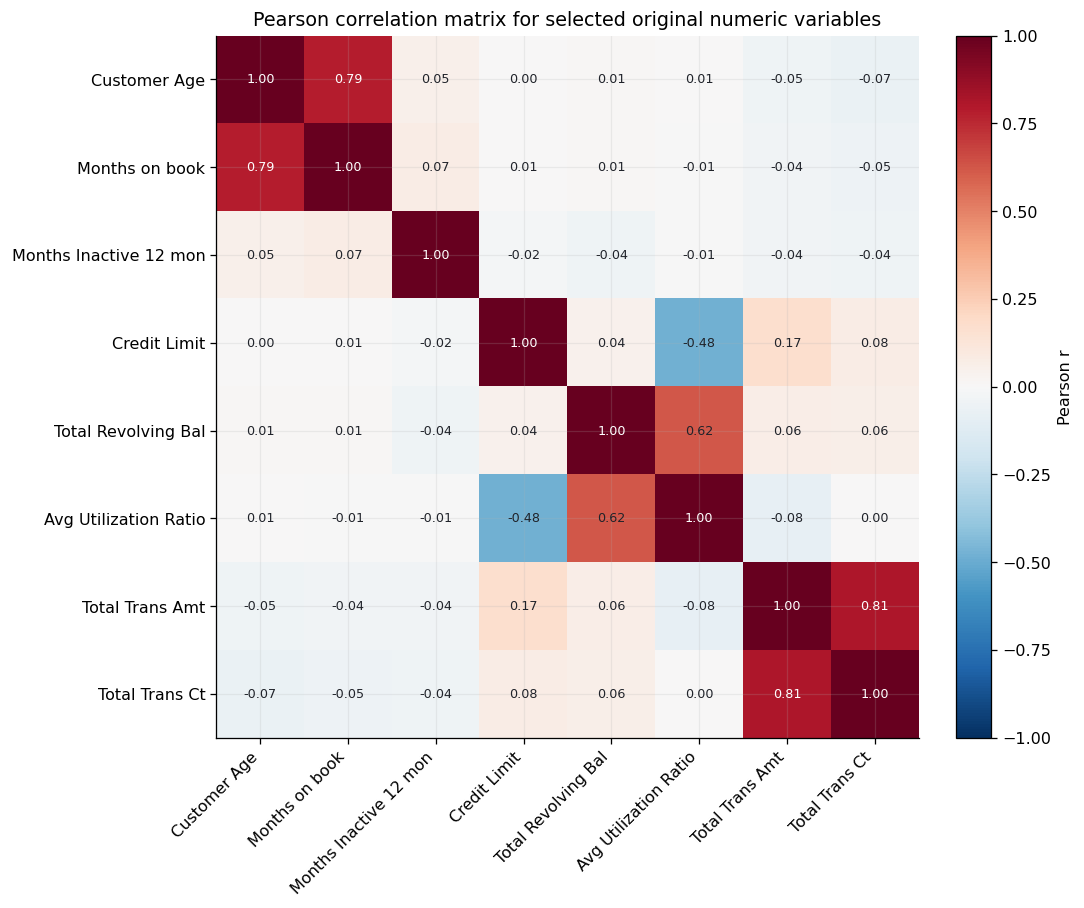

In [14]:
numeric_cols = ['Customer_Age', 'Months_on_book', 'Months_Inactive_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Utilization_Ratio', 'Total_Trans_Amt', 'Total_Trans_Ct']
matrix = df[numeric_cols].corr(method='pearson')
fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(matrix, cmap='RdBu_r', norm=TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1))
ax.set_xticks(range(len(numeric_cols)), [s.replace('_', ' ') for s in numeric_cols], rotation=45, ha='right')
ax.set_yticks(range(len(numeric_cols)), [s.replace('_', ' ') for s in numeric_cols])
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        value = matrix.iloc[i,j]
        ax.text(j, i, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value)>.65 else '#20232a')
fig.colorbar(image, ax=ax, fraction=.046, pad=.04, label='Pearson r')
ax.set_title('Pearson correlation matrix for selected original numeric variables')
fig.tight_layout()
plt.show()

**Figure 10.** The strongest positive off-diagonal value is **transaction amount versus count, r ≈ 0.807** (Figure 1 agrees). The strongest negative is **credit limit versus utilization, r ≈ −0.483**; Figure 3 shows why that single coefficient hides a nonlinear shape. A weak example is **age versus credit limit, r ≈ 0.0025**. Age versus months on book is also high (≈0.789), which may reflect life-cycle structure and should not be treated as an independent effect.

## 9. Two further bivariate views

The hexbin chart separates density from overplotting for pair 1. The decile chart summarizes the unstable relationship in pair 2 without relying on a straight-line fit. Quantile bins are computed from the original data, with repeated cap values handled using `duplicates='drop'`.

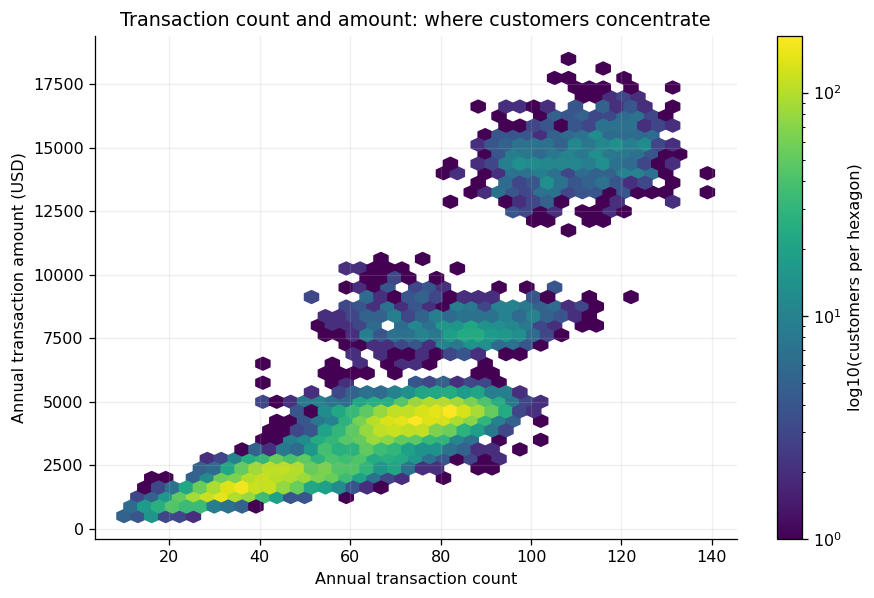

In [15]:
fig, ax = plt.subplots(figsize=(8, 5.3))
mesh = ax.hexbin(df['Total_Trans_Ct'], df['Total_Trans_Amt'], gridsize=42, mincnt=1, bins='log', cmap='viridis')
fig.colorbar(mesh, ax=ax, label='log10(customers per hexagon)')
ax.set(title='Transaction count and amount: where customers concentrate', xlabel='Annual transaction count', ylabel='Annual transaction amount (USD)')
fig.tight_layout()
plt.show()

**Figure 11, additional bivariate view 2.** The most populated cells form an increasing band, confirming the positive count–amount relation. The hexbin also shows how sparse the very high spending region is; Figure 1's scattered points alone can overemphasize isolated cases.

                    limit_med  amount_med     n
limit_decile                                   
(1438.299, 1762.0]    1438.65      3966.5  1014
(1762.0, 2307.2]      2055.00      4098.5  1012
(2307.2, 2787.0]      2555.00      4087.0  1014
(2787.0, 3398.4]      3068.00      3946.0  1011
(3398.4, 4549.0]      3890.00      3972.0  1015
(4549.0, 6279.2]      5364.50      3708.5  1010
(6279.2, 9078.4]      7567.00      3700.0  1013
(9078.4, 13562.6]    11067.50      3695.5  1012
(13562.6, 23400.2]   17450.00      3749.0  1013
(23400.2, 34516.0]   34516.00      3920.0  1013


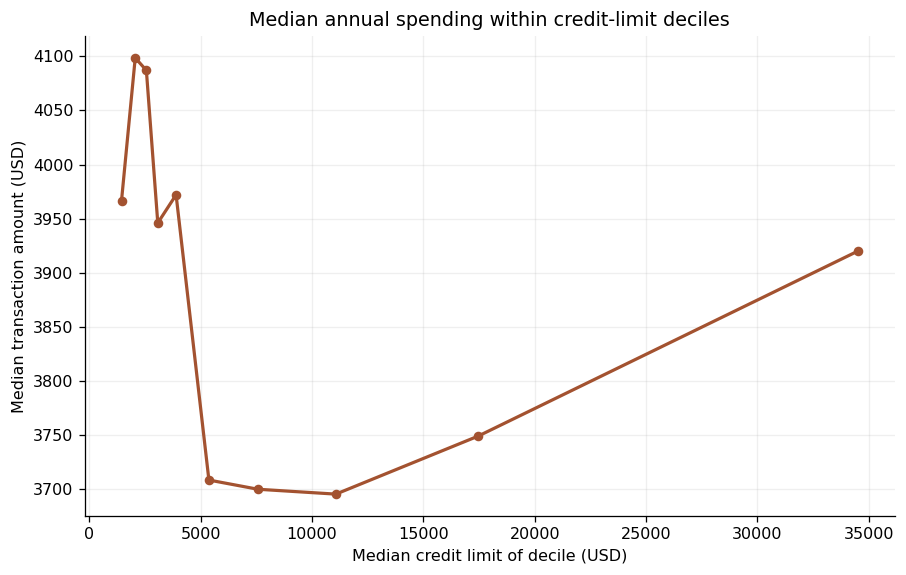

In [16]:
deciles = (df.assign(limit_decile=pd.qcut(df['Credit_Limit'], q=10, duplicates='drop'))
           .groupby('limit_decile', observed=True)
           .agg(limit_med=('Credit_Limit', 'median'), amount_med=('Total_Trans_Amt', 'median'), n=('CLIENTNUM', 'size')))
fig, ax = plt.subplots(figsize=(8, 5.1))
ax.plot(deciles['limit_med'], deciles['amount_med'], '-o', color='#a35230', lw=2, ms=5)
ax.set(title='Median annual spending within credit-limit deciles', xlabel='Median credit limit of decile (USD)', ylabel='Median transaction amount (USD)')
fig.tight_layout()
plt.show()
print(deciles.to_string())

**Figure 12, further bivariate check.** Median spending changes much less than individual spending across most limit bands and is not a simple straight-line increase. The plot reinforces the near-zero Spearman coefficient and weak Pearson coefficient for limit versus amount. The last band includes many customers at the cap, so its x-coordinate represents a compressed range.

## 10. Association is not causation

The strong transaction count–amount correlation is partly arithmetic: total spending is the sum of individual transaction amounts, so making more purchases mechanically creates more opportunities for a larger total. Yet average ticket size varies, and both counts and amounts can respond to income, consumption needs, available credit, rewards, seasonality, or tenure. The file is observational and does not give randomized interventions or temporal ordering for these annual aggregates. We therefore cannot claim that causing a customer to make one more transaction would produce the cross-sectional slope implied by the scatterplot. Likewise, credit limit and utilization share a denominator by definition. Selection into this bank's cardholder sample and attrition groups may further change observed associations.

## 11. New EDA questions

1. Within **similar transaction-count bands**, do attrited and existing customers differ in median transaction size (`Total_Trans_Amt / Total_Trans_Ct`)? This goes beyond comparing the two original activity variables separately.
2. Does the limit–spending relationship differ within **income categories**, especially after handling the $34,516 limit cap?
3. Is the nonlinear limit–utilization pattern still visible **within card categories** and among customers with a positive revolving balance?
4. Are the high-spending outliers concentrated in particular **transaction-count and card-category combinations**?

## 12. Final interpretation 

The strongest substantively useful numerical relationship in the selected correlation matrix is between annual transaction count and annual transaction amount. Across 10,127 customers, Pearson's r is 0.807 and Spearman's rho is 0.880. The scatterplot and hexbin chart both show a clear increasing band: customers who make more transactions generally spend more in total. The higher rank correlation suggests that the overall increase is more regular in ordering than it is linear in dollar units. This relationship is partly arithmetic, because total amount accumulates across transactions, but the broadening cloud shows that transaction size varies considerably.

The most interesting contrast is credit limit versus transaction amount. Pearson's r is only 0.172, while Spearman's rho is approximately 0.028. The scatterplot contains many different spending levels at a given limit and a visible stack at the $34,516 cap. Thus, a larger available limit is not a reliable indicator of where a customer's spending ranks. The high monetary tails matter collectively: Pearson falls to about 0.027 after excluding all 896 transaction-amount observations above Assignment 2's IQR fence. Excluding just two investigated extreme customers changes Pearson from 0.1717 to 0.1721, so those individuals do not drive the result. Their records are plausible and remain in the principal analysis.

An additional pair, credit limit and utilization ratio, reveals a nonlinear pattern. Binned median utilization initially increases at low limits, then declines strongly as limits rise and approaches zero at high limits. Pearson's −0.483 summarizes the negative overall tendency but misses that initial rise. This association is partly built into the ratio's denominator and should not be interpreted as an effect of increasing a limit.

Grouping the count–amount relationship by attrition status leaves the positive direction intact: Pearson is about 0.827 for attrited and 0.813 for existing customers. It also reveals that the attrited group has lower typical activity and fewer customers in the high-activity region. Their spending distributions nevertheless overlap. Next, a useful question is whether typical amount **per transaction** differs by attrition status within the same count bands. These cross-sectional associations do not establish causation: individual purchase size, income, product choice, selection into card categories, and other unobserved factors may affect both variables, and the dataset supplies no randomized or time-ordered evidence.